# Walk-Forward Validation

This notebook evaluates the pairs-trading strategy using an expanding-window walk-forward validation scheme.

In each fold:

1. The training period expands through time.
2. Candidate pairs are selected using training data only.
3. Directed pairs are selected by Sharpe ratio in training period.
4. The selected strategies are evaluated over the next calendar year.

This will give us an insight into whether the strategy generalizes through time.

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/nordi/Desktop/pairs-trading-backtest')

In [5]:
from src.data import download_prices
from src.pairs_trading import (
    compute_simple_returns,
    rank_pairs_by_correlation,
    compute_rolling_spread,
    run_dynamic_beta_backtest,
    estimate_ou_parameters,
)

## Data
Same ETF universe and sample period as the previous notebooks. The data is daily adjusted close prices.

In [8]:
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

start = "2015-01-01"
end = "2026-01-01"

prices = download_prices(
    tickers=tickers,
    start=start,
    end=end,
)

returns = compute_simple_returns(prices)

print("prices:", prices.shape)
print("returns:", returns.shape)

prices.head()

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
prices: (2766, 15)
returns: (2765, 15)


,SPY,QQQ,IWM,XLK,XLF,XLE,XLV,XLY,XLP,XLI,XLU,TLT,HYG,LQD,GLD
Date,,,,,,,,,,,,,,,
2015-01-02,169.687866,94.561134,102.543121,18.062738,16.217979,25.365137,56.807293,31.573736,35.618256,46.097977,16.406504,92.659241,48.571236,80.124290,114.080002
2015-01-05,166.623337,93.174057,101.172203,17.786995,15.876958,24.315830,56.517605,30.969851,35.367790,45.021183,16.205923,94.114807,48.121277,80.451912,115.800003
2015-01-06,165.053925,91.924744,99.421921,17.572544,15.634314,23.958616,56.327225,30.661303,35.323582,44.466480,16.216291,95.810455,47.936970,80.779549,117.120003
2015-01-07,167.110687,93.109741,100.646263,17.721348,15.798264,24.009644,57.651592,31.146170,35.927650,44.800945,16.375380,95.621239,48.235123,80.886536,116.430000
2015-01-08,170.076004,94.891846,102.353447,18.110880,16.034355,24.548655,58.636589,31.613401,36.472797,45.698257,16.489502,94.354973,48.598339,80.625763,115.940002


## Strategy Settings
The same baseline strategy parameters are used here. The only difference is that pair selection and out-of-sample testing are repeated across multiple expanding-window folds.

In [12]:
# strategy parameters
hedge_window = 252
zscore_window = 120
entry_threshold = 2.0
exit_threshold = 0.5
transaction_cost_bps = 5.0

n_candidate_pairs = 10
n_selected_pairs = 5

In [14]:
def select_directed_pairs(
    prices: pd.DataFrame,
    train_start: str,
    train_end: str,
    n_candidate_pairs: int = 10,
    n_selected_pairs: int = 5,
) -> pd.DataFrame:
    """
    Select directed pairs using training-period information only.

    Candidate pairs are ranked by training return correlation.
    Both regression directions are tested in the training period.
    The top directed pairs are selected by training Sharpe ratio.
    """
    train_prices = prices.loc[train_start:train_end]
    train_returns = compute_simple_returns(train_prices)

    ranked_pairs = rank_pairs_by_correlation(train_returns)
    candidate_pairs = ranked_pairs.head(n_candidate_pairs)

    results = []

    for _, row in candidate_pairs.iterrows():
        ticker_a = row["ticker_1"]
        ticker_b = row["ticker_2"]
        train_correlation = row["correlation"]

        for ticker_y, ticker_x in [(ticker_a, ticker_b), (ticker_b, ticker_a)]:
            try:
                metrics = run_dynamic_beta_backtest(
                    prices=prices,
                    ticker_y=ticker_y,
                    ticker_x=ticker_x,
                    hedge_window=hedge_window,
                    zscore_window=zscore_window,
                    entry_threshold=entry_threshold,
                    exit_threshold=exit_threshold,
                    transaction_cost_bps=transaction_cost_bps,
                    evaluation_start=train_start,
                    evaluation_end=train_end,
                    max_holding_days=None,
                )

                metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
                metrics["ticker_y"] = ticker_y
                metrics["ticker_x"] = ticker_x
                metrics["train_correlation"] = train_correlation

                results.append(metrics)

            except Exception as e:
                print(f"Failed on Y={ticker_y}, X={ticker_x}: {e}")

    results_df = pd.DataFrame(results)

    selected_pairs = (
        results_df
        .sort_values("sharpe_ratio", ascending=False)
        .head(n_selected_pairs)
        .copy()
    )

    return selected_pairs

In [16]:
def evaluate_selected_pairs(
    prices: pd.DataFrame,
    selected_pairs: pd.DataFrame,
    test_start: str,
    test_end: str,
) -> pd.DataFrame:
    """
    Evaluate selected directed pairs over an out-of-sample test period.
    """
    results = []

    for _, row in selected_pairs.iterrows():
        ticker_y = row["ticker_y"]
        ticker_x = row["ticker_x"]

        metrics = run_dynamic_beta_backtest(
            prices=prices,
            ticker_y=ticker_y,
            ticker_x=ticker_x,
            hedge_window=hedge_window,
            zscore_window=zscore_window,
            entry_threshold=entry_threshold,
            exit_threshold=exit_threshold,
            transaction_cost_bps=transaction_cost_bps,
            evaluation_start=test_start,
            evaluation_end=test_end,
            max_holding_days=None,
        )

        metrics["pair"] = f"Y={ticker_y}/X={ticker_x}"
        metrics["ticker_y"] = ticker_y
        metrics["ticker_x"] = ticker_x
        metrics["train_correlation"] = row["train_correlation"]
        metrics["train_sharpe"] = row["sharpe_ratio"]

        results.append(metrics)

    return pd.DataFrame(results)

## Walk-Forward Folds

Each fold uses all data available up to the end of the training period, then evaluates performance over the next calendar year.

In [19]:
walk_forward_folds = [
    {
        "fold": 1,
        "train_start": "2015-01-01",
        "train_end": "2018-12-31",
        "test_start": "2019-01-01",
        "test_end": "2019-12-31",
    },
    {
        "fold": 2,
        "train_start": "2015-01-01",
        "train_end": "2019-12-31",
        "test_start": "2020-01-01",
        "test_end": "2020-12-31",
    },
    {
        "fold": 3,
        "train_start": "2015-01-01",
        "train_end": "2020-12-31",
        "test_start": "2021-01-01",
        "test_end": "2021-12-31",
    },
    {
        "fold": 4,
        "train_start": "2015-01-01",
        "train_end": "2021-12-31",
        "test_start": "2022-01-01",
        "test_end": "2022-12-31",
    },
    {
        "fold": 5,
        "train_start": "2015-01-01",
        "train_end": "2022-12-31",
        "test_start": "2023-01-01",
        "test_end": "2023-12-31",
    },
    {
        "fold": 6,
        "train_start": "2015-01-01",
        "train_end": "2023-12-31",
        "test_start": "2024-01-01",
        "test_end": "2024-12-31",
    },
    {
        "fold": 7,
        "train_start": "2015-01-01",
        "train_end": "2024-12-31",
        "test_start": "2025-01-01",
        "test_end": "2025-12-31",
    },
]

pd.DataFrame(walk_forward_folds)

,fold,train_start,train_end,test_start,test_end
0,1,2015-01-01,2018-12-31,2019-01-01,2019-12-31
1,2,2015-01-01,2019-12-31,2020-01-01,2020-12-31
2,3,2015-01-01,2020-12-31,2021-01-01,2021-12-31
3,4,2015-01-01,2021-12-31,2022-01-01,2022-12-31
4,5,2015-01-01,2022-12-31,2023-01-01,2023-12-31
5,6,2015-01-01,2023-12-31,2024-01-01,2024-12-31
6,7,2015-01-01,2024-12-31,2025-01-01,2025-12-31


In [21]:
walk_forward_results = []

for fold_info in walk_forward_folds:
    fold = fold_info["fold"]
    train_start = fold_info["train_start"]
    train_end = fold_info["train_end"]
    test_start = fold_info["test_start"]
    test_end = fold_info["test_end"]

    print(
        f"Fold {fold}: "
        f"Train {train_start} to {train_end} -> "
        f"Test {test_start} to {test_end}"
    )

    selected_pairs = select_directed_pairs(
        prices=prices,
        train_start=train_start,
        train_end=train_end,
        n_candidate_pairs=n_candidate_pairs,
        n_selected_pairs=n_selected_pairs,
    )

    fold_results = evaluate_selected_pairs(
        prices=prices,
        selected_pairs=selected_pairs,
        test_start=test_start,
        test_end=test_end,
    )

    fold_results["fold"] = fold
    fold_results["train_start"] = train_start
    fold_results["train_end"] = train_end
    fold_results["test_start"] = test_start
    fold_results["test_end"] = test_end

    walk_forward_results.append(fold_results)

walk_forward_results = pd.concat(walk_forward_results, ignore_index=True)

walk_forward_results.shape

Fold 1: Train 2015-01-01 to 2018-12-31 -> Test 2019-01-01 to 2019-12-31
Fold 2: Train 2015-01-01 to 2019-12-31 -> Test 2020-01-01 to 2020-12-31
Fold 3: Train 2015-01-01 to 2020-12-31 -> Test 2021-01-01 to 2021-12-31
Fold 4: Train 2015-01-01 to 2021-12-31 -> Test 2022-01-01 to 2022-12-31
Fold 5: Train 2015-01-01 to 2022-12-31 -> Test 2023-01-01 to 2023-12-31
Fold 6: Train 2015-01-01 to 2023-12-31 -> Test 2024-01-01 to 2024-12-31
Fold 7: Train 2015-01-01 to 2024-12-31 -> Test 2025-01-01 to 2025-12-31


(35, 19)

In [23]:
walk_forward_results[
    [
        "fold",
        "test_start",
        "test_end",
        "pair",
        "ticker_y",
        "ticker_x",
        "train_correlation",
        "train_sharpe",
        "total_return",
        "annualized_return",
        "annualized_volatility",
        "sharpe_ratio",
        "max_drawdown",
        "n_trades",
        "win_rate",
        "avg_holding_days",
        "days_in_market_frac",
    ]
].round(4)

,fold,test_start,test_end,pair,ticker_y,ticker_x,train_correlation,train_sharpe,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,n_trades,win_rate,avg_holding_days,days_in_market_frac
0,1,2019-01-01,2019-12-31,Y=XLI/X=SPY,XLI,SPY,0.9087,1.1469,0.0223,0.0223,0.0162,1.3680,-0.0075,3,1.0000,15.3333,0.1706
1,1,2019-01-01,2019-12-31,Y=SPY/X=XLI,SPY,XLI,0.9087,0.7145,0.0257,0.0257,0.0239,1.0723,-0.0086,4,1.0000,23.7500,0.3611
2,1,2019-01-01,2019-12-31,Y=XLK/X=SPY,XLK,SPY,0.9180,0.5097,0.0203,0.0203,0.0145,1.3894,-0.0095,4,1.0000,18.5000,0.2778
3,1,2019-01-01,2019-12-31,Y=LQD/X=TLT,LQD,TLT,0.8515,0.4129,-0.0212,-0.0212,0.0204,-1.0366,-0.0384,3,0.3333,34.0000,0.3929
4,1,2019-01-01,2019-12-31,Y=SPY/X=XLK,SPY,XLK,0.9180,0.3964,0.0270,0.0270,0.0120,2.2311,-0.0047,4,1.0000,8.7500,0.1230
5,2,2020-01-01,2020-12-31,Y=XLI/X=SPY,XLI,SPY,0.9014,1.1910,-0.1064,-0.1060,0.0648,-1.6972,-0.1256,1,0.0000,71.0000,0.6008
6,2,2020-01-01,2020-12-31,Y=SPY/X=XLI,SPY,XLI,0.9014,0.8230,-0.0015,-0.0015,0.0570,0.0012,-0.0678,4,0.5000,21.7500,0.4980
7,2,2020-01-01,2020-12-31,Y=SPY/X=XLK,SPY,XLK,0.9192,0.7430,-0.0471,-0.0469,0.0565,-0.8211,-0.0912,3,0.6667,37.0000,0.4269
8,2,2020-01-01,2020-12-31,Y=XLK/X=SPY,XLK,SPY,0.9192,0.7229,-0.1066,-0.1062,0.0595,-1.8556,-0.1221,2,0.0000,60.0000,0.7628
9,2,2020-01-01,2020-12-31,Y=XLK/X=QQQ,XLK,QQQ,0.9729,0.3355,0.0092,0.0092,0.0199,0.4688,-0.0095,5,0.8000,18.4000,0.3439


In [25]:
fold_summary = (
    walk_forward_results
    .groupby(["fold", "test_start", "test_end"])
    .agg(
        avg_total_return=("total_return", "mean"),
        avg_annualized_return=("annualized_return", "mean"),
        avg_volatility=("annualized_volatility", "mean"),
        avg_sharpe=("sharpe_ratio", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        total_trades=("n_trades", "sum"),
        avg_win_rate=("win_rate", "mean"),
        avg_holding_days=("avg_holding_days", "mean"),
        avg_days_in_market=("days_in_market_frac", "mean"),
    )
    .reset_index()
)

fold_summary.round(4)

,fold,test_start,test_end,avg_total_return,avg_annualized_return,avg_volatility,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days,avg_days_in_market
0,1,2019-01-01,2019-12-31,0.0148,0.0148,0.0174,1.0048,-0.0137,18,0.8667,20.0667,0.2651
1,2,2020-01-01,2020-12-31,-0.0505,-0.0503,0.0515,-0.7808,-0.0833,15,0.3933,41.6300,0.5265
2,3,2021-01-01,2021-12-31,-0.0026,-0.0026,0.0272,0.1054,-0.0334,20,0.6333,23.1867,0.3397
3,4,2022-01-01,2022-12-31,0.0119,0.0119,0.0340,0.3836,-0.0282,18,0.7000,28.0867,0.4653
4,5,2023-01-01,2023-12-31,0.0034,0.0034,0.0249,0.0891,-0.0275,14,0.5833,40.3333,0.4160
5,6,2024-01-01,2024-12-31,0.0330,0.0330,0.0247,1.4125,-0.0132,24,0.9600,14.6100,0.2722
6,7,2025-01-01,2025-12-31,0.0015,0.0016,0.0309,0.2465,-0.0319,18,0.6933,28.5767,0.4368


In [27]:
overall_walk_forward_summary = pd.DataFrame(
    {
        "avg_fold_total_return": [fold_summary["avg_total_return"].mean()],
        "avg_fold_annualized_return": [fold_summary["avg_annualized_return"].mean()],
        "avg_fold_volatility": [fold_summary["avg_volatility"].mean()],
        "avg_fold_sharpe": [fold_summary["avg_sharpe"].mean()],
        "avg_fold_max_drawdown": [fold_summary["avg_max_drawdown"].mean()],
        "total_trades": [fold_summary["total_trades"].sum()],
        "avg_fold_win_rate": [fold_summary["avg_win_rate"].mean()],
        "avg_fold_holding_days": [fold_summary["avg_holding_days"].mean()],
        "avg_fold_days_in_market": [fold_summary["avg_days_in_market"].mean()],
    }
)

overall_walk_forward_summary.round(4)

,avg_fold_total_return,avg_fold_annualized_return,avg_fold_volatility,avg_fold_sharpe,avg_fold_max_drawdown,total_trades,avg_fold_win_rate,avg_fold_holding_days,avg_fold_days_in_market
0,0.0017,0.0017,0.0301,0.3516,-0.033,127,0.69,28.07,0.3888


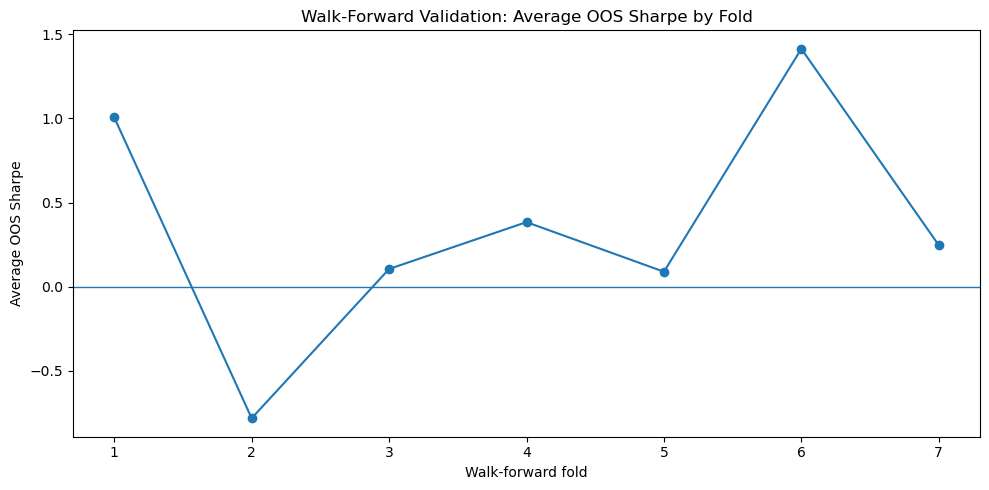

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    fold_summary["fold"],
    fold_summary["avg_sharpe"],
    marker="o",
)

plt.axhline(0, linewidth=1)
plt.xlabel("Walk-forward fold")
plt.ylabel("Average OOS Sharpe")
plt.title("Walk-Forward Validation: Average OOS Sharpe by Fold")
plt.tight_layout()
plt.show()

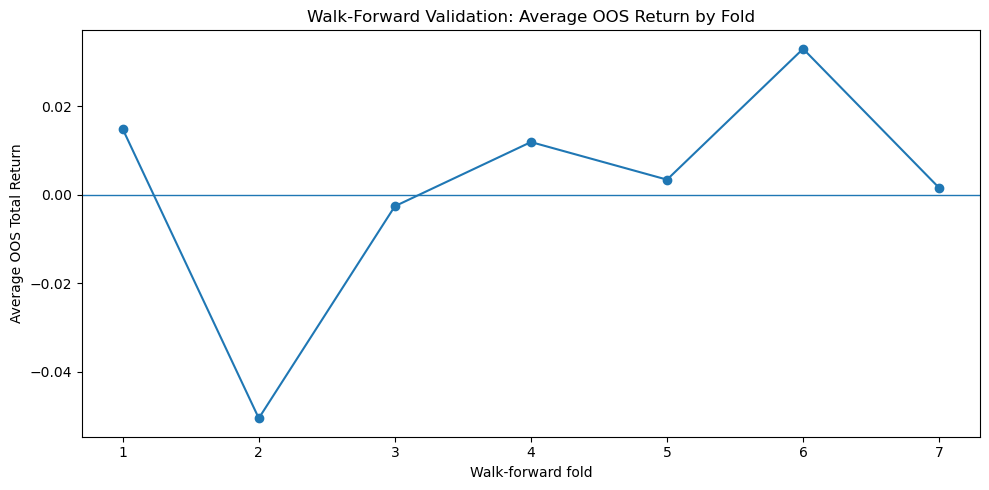

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    fold_summary["fold"],
    fold_summary["avg_total_return"],
    marker="o",
)

plt.axhline(0, linewidth=1)
plt.xlabel("Walk-forward fold")
plt.ylabel("Average OOS Total Return")
plt.title("Walk-Forward Validation: Average OOS Return by Fold")
plt.tight_layout()
plt.show()

In [33]:
pair_selection_counts = (
    walk_forward_results["pair"]
    .value_counts()
    .reset_index()
)

pair_selection_counts.columns = ["pair", "times_selected"]

pair_selection_counts

,pair,times_selected
0,Y=SPY/X=XLK,6
1,Y=XLK/X=QQQ,6
2,Y=SPY/X=XLI,5
3,Y=QQQ/X=XLK,5
4,Y=XLI/X=XLF,4
5,Y=XLI/X=IWM,3
6,Y=XLI/X=SPY,2
7,Y=XLK/X=SPY,2
8,Y=LQD/X=TLT,1
9,Y=XLY/X=XLK,1


In [35]:
pair_performance_summary = (
    walk_forward_results
    .groupby("pair")
    .agg(
        times_selected=("pair", "count"),
        avg_total_return=("total_return", "mean"),
        avg_sharpe=("sharpe_ratio", "mean"),
        avg_max_drawdown=("max_drawdown", "mean"),
        total_trades=("n_trades", "sum"),
        avg_win_rate=("win_rate", "mean"),
        avg_holding_days=("avg_holding_days", "mean"),
    )
    .sort_values("avg_sharpe", ascending=False)
)

pair_performance_summary.round(4)

,times_selected,avg_total_return,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days
pair,,,,,,,
Y=SPY/X=XLK,6,0.0169,1.0431,-0.0271,23,0.9028,18.1000
Y=XLK/X=QQQ,6,0.0105,0.6240,-0.0166,26,0.7722,24.1944
Y=XLY/X=XLK,1,0.0277,0.5262,-0.0420,3,0.3333,30.6667
Y=QQQ/X=XLK,5,0.0084,0.4812,-0.0165,20,0.6600,30.1300
Y=XLI/X=XLF,4,0.0052,0.1678,-0.0340,13,0.6167,32.7250
Y=SPY/X=XLI,5,0.0005,0.0852,-0.0368,18,0.7333,25.9867
Y=XLI/X=IWM,3,-0.0027,0.0352,-0.0486,11,0.6667,29.2333
Y=XLI/X=SPY,2,-0.0421,-0.1646,-0.0665,4,0.5000,43.1667
Y=XLK/X=SPY,2,-0.0432,-0.2331,-0.0658,6,0.5000,39.2500


## Walk-Forward Interpretation

The walk-forward validation gives a stricter test than a single fixed train/test split. Instead of selecting pairs once and evaluating them over a single test period, this procedure repeatedly reselects pairs using only information available up to that point and then evaluates the selected pairs over the next calendar year.

This helps reveal whether performance is stable through time or concentrated in a small number of favorable periods. If the fold-level Sharpe ratios vary substantially, then the strategy is regime-dependent. If the same pairs are selected repeatedly and perform well across multiple folds, then the result is more stable.

The pair-selection counts also show whether the strategy consistently identifies the same relationships or whether selected pairs change substantially across folds.

In [38]:
selected_pairs_by_fold = (
    walk_forward_results
    .sort_values(["fold", "sharpe_ratio"], ascending=[True, False])
    [
        [
            "fold",
            "test_start",
            "test_end",
            "pair",
            "train_correlation",
            "train_sharpe",
            "total_return",
            "sharpe_ratio",
            "n_trades",
        ]
    ]
)

selected_pairs_by_fold.round(4)

,fold,test_start,test_end,pair,train_correlation,train_sharpe,total_return,sharpe_ratio,n_trades
4,1,2019-01-01,2019-12-31,Y=SPY/X=XLK,0.9180,0.3964,0.0270,2.2311,4
2,1,2019-01-01,2019-12-31,Y=XLK/X=SPY,0.9180,0.5097,0.0203,1.3894,4
0,1,2019-01-01,2019-12-31,Y=XLI/X=SPY,0.9087,1.1469,0.0223,1.3680,3
1,1,2019-01-01,2019-12-31,Y=SPY/X=XLI,0.9087,0.7145,0.0257,1.0723,4
3,1,2019-01-01,2019-12-31,Y=LQD/X=TLT,0.8515,0.4129,-0.0212,-1.0366,3
9,2,2020-01-01,2020-12-31,Y=XLK/X=QQQ,0.9729,0.3355,0.0092,0.4688,5
6,2,2020-01-01,2020-12-31,Y=SPY/X=XLI,0.9014,0.8230,-0.0015,0.0012,4
7,2,2020-01-01,2020-12-31,Y=SPY/X=XLK,0.9192,0.7430,-0.0471,-0.8211,3
5,2,2020-01-01,2020-12-31,Y=XLI/X=SPY,0.9014,1.1910,-0.1064,-1.6972,1
8,2,2020-01-01,2020-12-31,Y=XLK/X=SPY,0.9192,0.7229,-0.1066,-1.8556,2


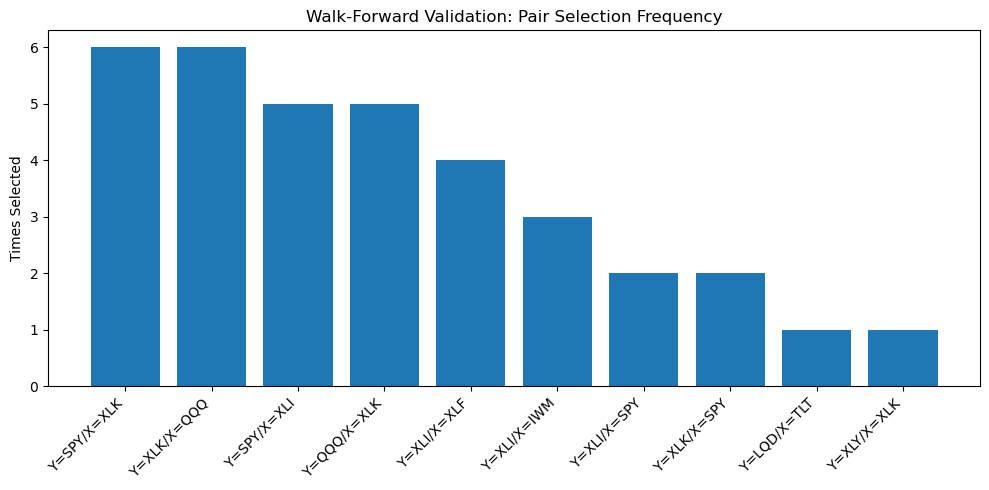

In [40]:
plt.figure(figsize=(10, 5))

plt.bar(
    pair_selection_counts["pair"],
    pair_selection_counts["times_selected"],
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Times Selected")
plt.title("Walk-Forward Validation: Pair Selection Frequency")
plt.tight_layout()
plt.show()

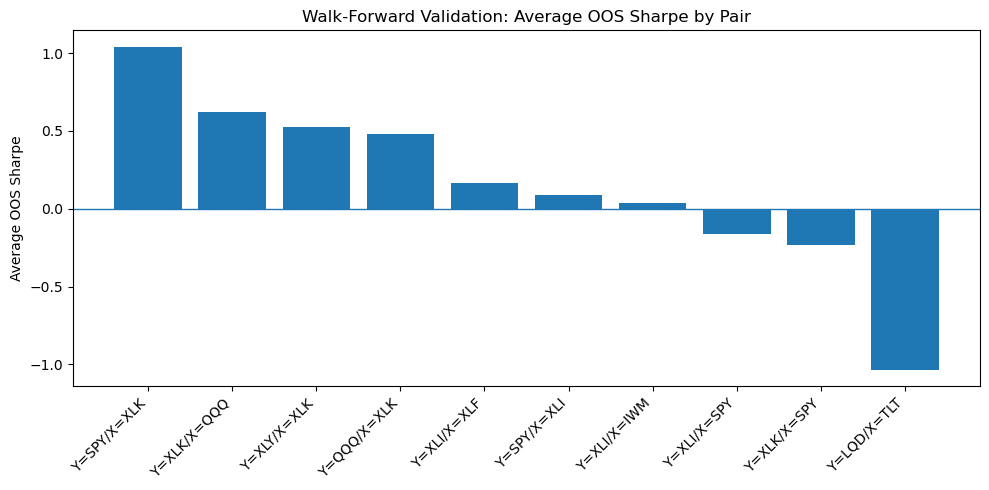

In [42]:
plot_df = pair_performance_summary.reset_index()

plt.figure(figsize=(10, 5))

plt.bar(
    plot_df["pair"],
    plot_df["avg_sharpe"],
)

plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average OOS Sharpe")
plt.title("Walk-Forward Validation: Average OOS Sharpe by Pair")
plt.tight_layout()
plt.show()

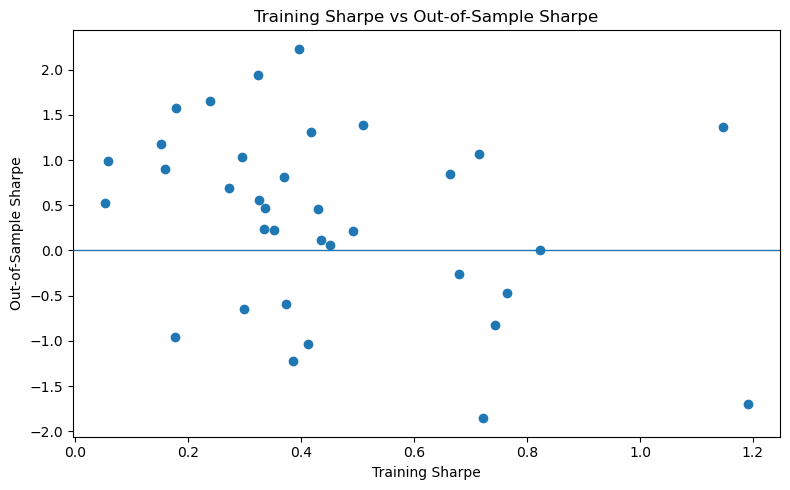

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    walk_forward_results["train_sharpe"],
    walk_forward_results["sharpe_ratio"],
)

plt.axhline(0, linewidth=1)
plt.xlabel("Training Sharpe")
plt.ylabel("Out-of-Sample Sharpe")
plt.title("Training Sharpe vs Out-of-Sample Sharpe")
plt.tight_layout()
plt.show()

In [46]:
train_oos_sharpe_corr = walk_forward_results[
    ["train_sharpe", "sharpe_ratio"]
].corr().loc["train_sharpe", "sharpe_ratio"]

train_oos_sharpe_corr

-0.3321904721428192

In [48]:
best_fold = fold_summary.sort_values("avg_sharpe", ascending=False).head(1)
worst_fold = fold_summary.sort_values("avg_sharpe", ascending=True).head(1)

display(best_fold.round(4))
display(worst_fold.round(4))

,fold,test_start,test_end,avg_total_return,avg_annualized_return,avg_volatility,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days,avg_days_in_market
5,6,2024-01-01,2024-12-31,0.033,0.033,0.0247,1.4125,-0.0132,24,0.96,14.61,0.2722


,fold,test_start,test_end,avg_total_return,avg_annualized_return,avg_volatility,avg_sharpe,avg_max_drawdown,total_trades,avg_win_rate,avg_holding_days,avg_days_in_market
1,2,2020-01-01,2020-12-31,-0.0505,-0.0503,0.0515,-0.7808,-0.0833,15,0.3933,41.63,0.5265


In [50]:
positive_fold_rate = (fold_summary["avg_sharpe"] > 0).mean()

positive_fold_rate

0.8571428571428571

In [52]:
final_walk_forward_summary = pd.DataFrame(
    {
        "n_folds": [len(fold_summary)],
        "positive_fold_rate": [positive_fold_rate],
        "avg_fold_total_return": [fold_summary["avg_total_return"].mean()],
        "avg_fold_sharpe": [fold_summary["avg_sharpe"].mean()],
        "median_fold_sharpe": [fold_summary["avg_sharpe"].median()],
        "best_fold_sharpe": [fold_summary["avg_sharpe"].max()],
        "worst_fold_sharpe": [fold_summary["avg_sharpe"].min()],
        "total_trades": [fold_summary["total_trades"].sum()],
    }
)

final_walk_forward_summary.round(4)

,n_folds,positive_fold_rate,avg_fold_total_return,avg_fold_sharpe,median_fold_sharpe,best_fold_sharpe,worst_fold_sharpe,total_trades
0,7,0.8571,0.0017,0.3516,0.2465,1.4125,-0.7808,127
